# Guided DDIM Reconstruction – `train_large_ladiff` model

Test the diffusion model trained with `train_large_ladiff.py` on pre-computed
`la_fbp` / `gt_fbp` volumes saved by the **Large_LA_Dataset** notebook.

**Pipeline:**
1. Load `la_fbp.npy` / `gt_fbp.npy` and the percentile norm sidecar JSON.
2. Load the matching projections from disk (same setup as Large_LA_Dataset).
3. Load the trained UNet checkpoint.
4. For each test slice: run Guided DDIM with per-slice sinogram consistency.
5. Compute PSNR and SSIM vs. ground truth.


## 1. Imports & Setup

In [1]:
import sys, importlib, json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path('/myhome/sdate')
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset

# ── Reconstruction ────────────────────────────────────────────────────────
from astra_torch.lamino import gd_reconstruction_masked

# ── Diffusion model / pipeline ────────────────────────────────────────────
from diffusers.models import UNet2DModel
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline

# ── Metrics ───────────────────────────────────────────────────────────────
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

import lovely_tensors as lt
lt.monkey_patch()

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")


zarr not installed


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda  |  PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe


## 2. Configuration

These parameters must match the **Large_LA_Dataset** notebook used to produce the saved volumes.

In [2]:
import torch


def fft_2D(x, s=None, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    if ortho:
        fft_image = torch.fft.fftn(x, s=s, norm='ortho', dim=dim)
    else:
        fft_image = torch.fft.fftn(x, s=s, dim=dim)
    return torch.fft.fftshift(fft_image, dim=dim)


def ifft_2D(x, ortho:bool=False, dim=[-1, -2]):
    # if len(x.shape) == 2:
    #     raise Exception("Expects at least dimensions (b, w, h)")
    f_space = torch.fft.ifftshift(x, dim=dim)
    # Perform inverse 2D Fourier Transform
    if ortho:
        return torch.fft.ifftn(f_space, norm='ortho', dim=dim)
    else:
        return torch.fft.ifftn(f_space, dim=dim)
    


In [3]:
# ── Must match Large_LA_Dataset notebook ──────────────────────────────────
FILE_IDX         = 10
DATA_PATH        = Path(f'/myhome/data/sdate/shared/compression_paper/small/file_{FILE_IDX}_extracted')
DOWNSCALE_FACTOR = 2.0
ANGULAR_RANGE_FRAC = 0.6   # fraction of projections used as la (must match notebook)
START_IDX        = 0
DET_SPACING_MM   = 1.0
LAMINO_ANGLE_DEG = 0.0

# ── Saved volume paths (output of Large_LA_Dataset) ───────────────────────
RECON_PATH = Path(f'/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction')
LA_FBP_PATH  = RECON_PATH / f'la_fbp_{FILE_IDX}.npy'
GT_FBP_PATH  = RECON_PATH / f'gt_fbp_{FILE_IDX}.npy'
NORM_JSON    = RECON_PATH / f'la_fbp_{FILE_IDX}_norm.json'

# ── Checkpoint (output of train_large_ladiff.py) ──────────────────────────
CHECKPOINT_PATH  = project_root / 'checkpoints' / 'ddpm_large_ladiff.pt'
TINY_MODEL       = False   # set True if trained with --tiny

# ── Inference ─────────────────────────────────────────────────────────────
NUM_INFERENCE_STEPS = 50

# ── Test slices: indices into the la_fbp volume (0 .. num_slices-1) ───────
# Set to None to test every TEST_STRIDE-th slice across the whole volume.
TEST_SLICE_INDICES = None   # e.g. [50, 100, 150] or None for automatic
TEST_STRIDE        = 20     # used when TEST_SLICE_INDICES is None

# ── Guidance hyperparams ──────────────────────────────────────────────────
GUIDANCE_MAX_EPOCHS = 5
GUIDANCE_LR         = 1e-3
GUIDANCE_BATCH_SIZE = 30

print("Configuration set ✅")


Configuration set ✅


## 3. Load Saved Volumes and Normalization

In [4]:
la_fbp = torch.tensor(np.load(LA_FBP_PATH))   # (num_slices, H, W)
gt_fbp = torch.tensor(np.load(GT_FBP_PATH))   # (num_slices, H, W)

print(f"la_fbp shape : {la_fbp.shape}  [{la_fbp.min():.4f}, {la_fbp.max():.4f}]")
print(f"gt_fbp shape : {gt_fbp.shape}  [{gt_fbp.min():.4f}, {gt_fbp.max():.4f}]")

# ── Normalization from sidecar JSON ───────────────────────────────────────
with open(NORM_JSON) as f:
    norm_cfg = json.load(f)

norm_min = float(norm_cfg['norm_min'])
norm_max = float(norm_cfg['norm_max'])
print(f"\nNorm (p1–p99): min={norm_min:.4f}, max={norm_max:.4f}")

# Normalization functions: raw ↔ [0, 1]
def normalize_fn(x):
    return (x - norm_min) / (norm_max - norm_min)

def denormalize_fn(x):
    return x * (norm_max - norm_min) + norm_min

NUM_SLICES, SLICE_H, SLICE_W = la_fbp.shape
print(f"\nVolume: {NUM_SLICES} slices of {SLICE_H}×{SLICE_W}")


la_fbp shape : torch.Size([440, 640, 640])  [-0.0547, 0.0490]
gt_fbp shape : torch.Size([440, 640, 640])  [-0.0411, 0.0551]

Norm (p1–p99): min=-0.0026, max=0.0074

Volume: 440 slices of 640×640


(<Figure size 800x1000 with 20 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}>,
         <Axes: title={'center': 'Layer 23'}>,
         <Axes: title={'center': 'Layer 46'}>,
         <Axes: title={'center': 'Layer 69'}>],
        [<Axes: title={'center': 'Layer 92'}>,
         <Axes: title={'center': 'Layer 115'}>,
         <Axes: title={'center': 'Layer 138'}>,
         <Axes: title={'center': 'Layer 161'}>],
        [<Axes: title={'center': 'Layer 184'}>,
         <Axes: title={'center': 'Layer 207'}>,
         <Axes: title={'center': 'Layer 231'}>,
         <Axes: title={'center': 'Layer 254'}>],
        [<Axes: title={'center': 'Layer 277'}>,
         <Axes: title={'center': 'Layer 300'}>,
         <Axes: title={'center': 'Layer 323'}>,
         <Axes: title={'center': 'Layer 346'}>],
        [<Axes: title={'center': 'Layer 369'}>,
         <Axes: title={'center': 'Layer 392'}>,
         <Axes: title={'center': 'Layer 415'}>,
         <Axes: title={'center': 'Layer 439'}>]], dt

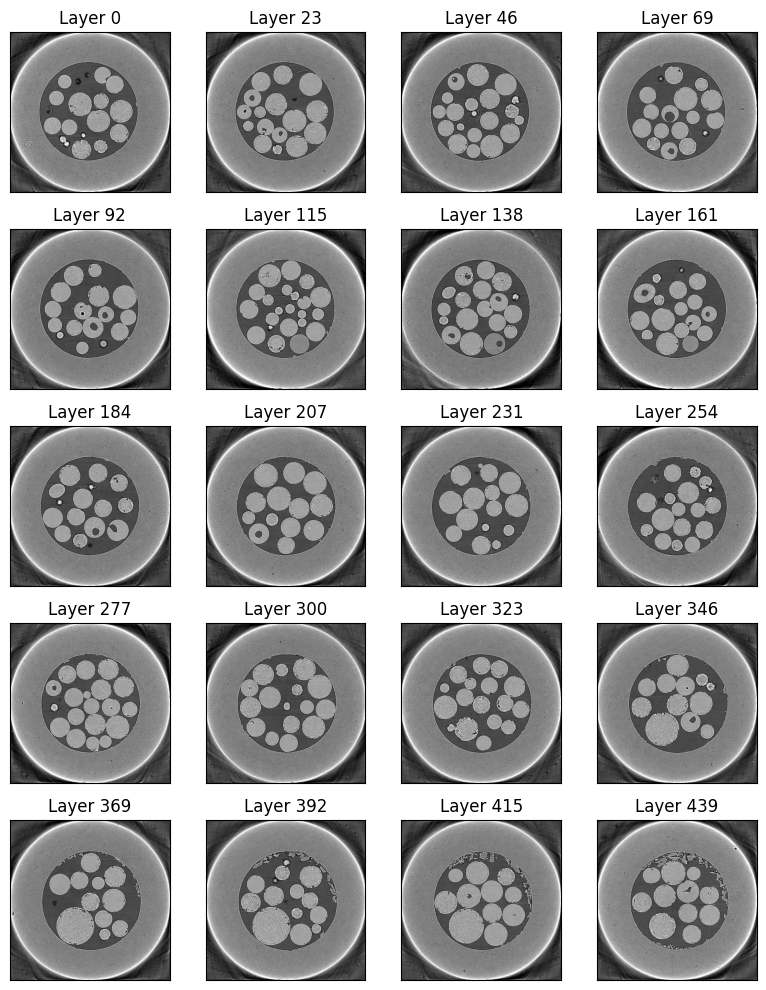

In [5]:
import matplotlib.pyplot as plt
import torch
import itertools

def plot_tomogram_overview(tomogram, rows=5, cols=4):
    # overview plot
    num_layers, width, height = tomogram.shape
    layers = np.linspace(0, num_layers - 1, rows * cols, dtype=int)
    fig, axes = plt.subplots(rows, cols, figsize=(2. * cols, 2. * rows), squeeze=False)

    for layer, ax in zip(layers, itertools.chain.from_iterable(axes)):
        img = tomogram[layer]
        ax.imshow(img, cmap='gray', vmin=norm_min, vmax=norm_max)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Layer {layer}")

    fig.subplots_adjust()
    fig.tight_layout()
    return fig, axes

plot_tomogram_overview(gt_fbp)

## 4. Load Projections

Re-load the projection data exactly as in Large_LA_Dataset to obtain `la_projections` and `la_angles_deg` for the guidance function.

In [6]:
# ── Probe dataset to get dimensions ───────────────────────────────────────
dataset_probe = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=1,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

TARGET_SIZE = (dataset_probe.volume.shape[1], dataset_probe.volume.shape[0])
TARGET_SIZE = (int(TARGET_SIZE[0] // DOWNSCALE_FACTOR), int(TARGET_SIZE[1]// DOWNSCALE_FACTOR))
NUM_PROJECTIONS = dataset_probe.processor.num_projections
ANGULAR_RANGE   = int(ANGULAR_RANGE_FRAC * NUM_PROJECTIONS)

print(f"NUM_PROJECTIONS : {NUM_PROJECTIONS}")
print(f"ANGULAR_RANGE   : {ANGULAR_RANGE}  ({ANGULAR_RANGE_FRAC*100:.0f}%)")
print(f"TARGET_SIZE     : {TARGET_SIZE}")

# ── Load full projection volume ────────────────────────────────────────────
dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=True,
)

# projections: (NUM_PROJECTIONS, H, W)  — each entry is one angular projection
projections = dataset.get_full_volume().permute(2, 0, 1)

# ── Limited-angle subset (must match Large_LA_Dataset) ────────────────────
full_angles_deg = -1 * torch.linspace(0, 180, NUM_PROJECTIONS).numpy()
la_projections  = projections[START_IDX : START_IDX + ANGULAR_RANGE]   # (ANGULAR_RANGE, H, W)
la_angles_deg   = full_angles_deg[START_IDX : START_IDX + ANGULAR_RANGE]



print(f"\nprojections  : {projections.shape}")
print(f"la_projections: {la_projections.shape}")
print(f"la angles    : {la_angles_deg[0]:.2f}° → {la_angles_deg[-1]:.2f}°")


Install with: pip install pillow-heif
✅ Found parameters in Al8Fe_10x_.log: {'num_darks': 32, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_10_extracted
   Total TIFF files: 1733
   Darks: 32, Flats: 100, Projections: 1501
   Image dimensions: 1280 x 881
   Use attenuation: False
ProjectionSliceDataset:
  Volume shape: (881, 1280, 1)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,127,680
Loading 1 projections...
Volume shape: (881, 1280, 1)
Total voxels: 1,127,680
Value range: [3910.0000, 22044.0000]
NUM_PROJECTIONS : 1501
ANGULAR_RANGE   : 900  (60%)
TARGET_SIZE     : (640, 440)
✅ Found parameters in Al8Fe_10x_.log: {'num_darks': 32, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_10_extracted
   Total TIFF files: 1733
   Darks: 32, Flats: 100, Projections: 1501
   Image dimensions: 1280 x 881
   Use attenuation: True
🔬 Loading dark and flat field images...


Loading flats: 100%|██████████| 100/100 [00:00<00:00, 187.10it/s]


   Dark average range: [96.00, 380.00]
   Flat average range: [24764.00, 60094.00]
ProjectionSliceDataset:
  Volume shape: (440, 640, 1501)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 281,600
Loading 1501 projections...
  Loaded 50/1501
  Loaded 100/1501
  Loaded 150/1501
  Loaded 200/1501
  Loaded 250/1501
  Loaded 300/1501
  Loaded 350/1501
  Loaded 400/1501
  Loaded 450/1501
  Loaded 500/1501
  Loaded 550/1501
  Loaded 600/1501
  Loaded 650/1501
  Loaded 700/1501
  Loaded 750/1501
  Loaded 800/1501
  Loaded 850/1501
  Loaded 900/1501
  Loaded 950/1501
  Loaded 1000/1501
  Loaded 1050/1501
  Loaded 1100/1501
  Loaded 1150/1501
  Loaded 1200/1501
  Loaded 1250/1501
  Loaded 1300/1501
  Loaded 1350/1501
  Loaded 1400/1501
  Loaded 1450/1501
  Loaded 1500/1501
Volume shape: (440, 640, 1501)
Total voxels: 422,681,600
Value range: [0.6507, 2.1720]

projections  : torch.Size([1501, 440, 640])
la_projections: torch.Size([900, 440, 640])
la angles    : -0.00° → -10

## 5. Visualise a Sample Slice

In [7]:
# NUM_SLICES = 5
# gt_fbp = gt_fbp[:NUM_SLICES]
# la_fbp = la_fbp[:NUM_SLICES]
# projections = projections[:, :NUM_SLICES]
# la_projections = la_projections[:, :NUM_SLICES]
# gt_fbp, la_fbp, projections, la_projections

NUM_SLICES = 1
gt_fbp = gt_fbp[:1].repeat(NUM_SLICES, 1, 1)   # repeat the first slice to create a "fake" volume of NUM_SLICES (for testing)
la_fbp = la_fbp[:1].repeat(NUM_SLICES, 1, 1)
projections = projections[:, :1].repeat(1, NUM_SLICES, 1)
la_projections = la_projections[:, :1].repeat(1, NUM_SLICES, 1)
gt_fbp, la_fbp, projections, la_projections

(tensor[1, 640, 640] n=409600 (1.6Mb) x∈[-0.013, 0.032] μ=0.002 σ=0.002,
 tensor[1, 640, 640] n=409600 (1.6Mb) x∈[-0.019, 0.031] μ=0.002 σ=0.002,
 tensor[1501, 1, 640] n=960640 (3.7Mb) x∈[0.803, 2.036] μ=1.381 σ=0.203,
 tensor[900, 1, 640] n=576000 (2.2Mb) x∈[0.832, 2.000] μ=1.387 σ=0.199)

In [12]:
projections = projections[::3]
full_angles_deg = full_angles_deg[::3]

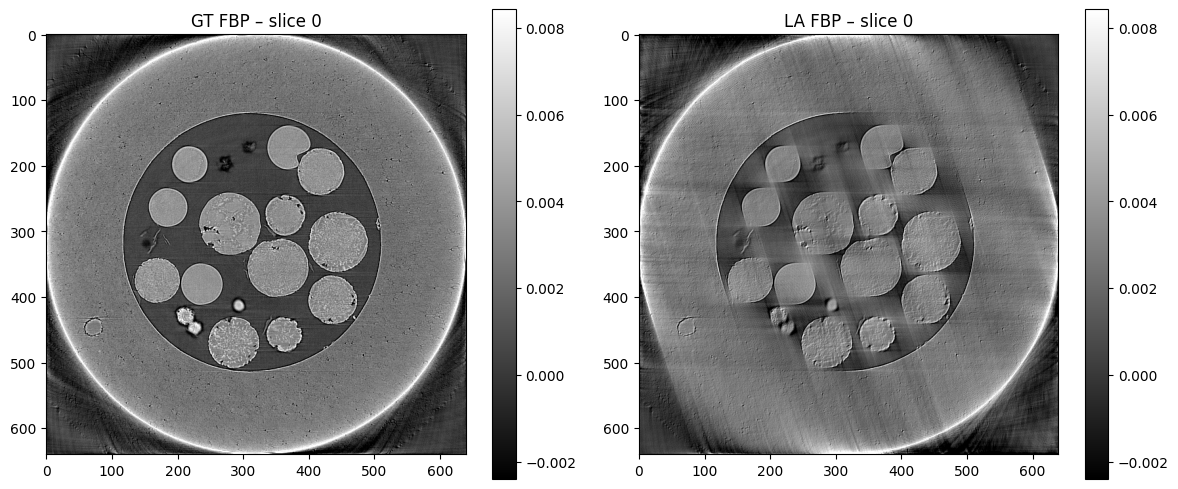

GT  range: [-0.0129, 0.0321]
LA  range: [-0.0187, 0.0314]
Norm [0,1] range covers p1=-0.0026 – p99=0.0074


In [13]:
PREVIEW_IDX = NUM_SLICES // 2

# PREVIEW_IDX = 0

gt_slice  = gt_fbp[PREVIEW_IDX]
la_slice  = la_fbp[PREVIEW_IDX]
vmin, vmax = np.percentile(gt_slice, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(gt_slice, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title(f'GT FBP – slice {PREVIEW_IDX}')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(la_slice, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'LA FBP – slice {PREVIEW_IDX}')
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

print(f"GT  range: [{gt_slice.min():.4f}, {gt_slice.max():.4f}]")
print(f"LA  range: [{la_slice.min():.4f}, {la_slice.max():.4f}]")
print(f"Norm [0,1] range covers p1={norm_min:.4f} – p99={norm_max:.4f}")


## 6. Load Trained Diffusion Model

In [14]:
CHECKPOINT_PATH = project_root / 'checkpoints' / 'ddpm_large_ladiff_file_10.pt'

In [15]:
channels = (32, 32, 32, 32, 64, 64) if TINY_MODEL else (64, 64, 128, 128, 256, 256)
model = UNet2DModel(
    sample_size=SLICE_W,   # slices are (SLICE_H, SLICE_W); model expects square → use W
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=channels,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D",
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
        "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"  Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"  in/out channels: 1 / 1  (single 2-D slice)")




Model loaded from /myhome/sdate/checkpoints/ddpm_large_ladiff_file_10.pt
  Parameters : 28,444,929
  in/out channels: 1 / 1  (single 2-D slice)


tensor[640, 640] n=409600 (1.6Mb) x∈[-0.107, 1.000] μ=0.469 σ=0.170 cuda:0

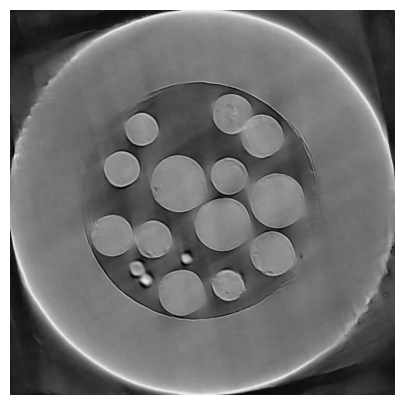

In [16]:
scheduler = GuidedDDIMScheduler(1000)
scheduler.set_timesteps(NUM_INFERENCE_STEPS)
timestep = 200
x_t = scheduler.add_noise(normalize_fn(gt_slice).clip(0, 1), torch.randn_like(gt_slice), timesteps=torch.tensor([timestep])).to(device)
with torch.no_grad():
    noise_pred = model(x_t.unsqueeze(0).unsqueeze(0), timestep = torch.tensor([timestep]).to(device), return_dict=False)[0].squeeze()  # (H, W)
    x_0_pred = scheduler.step(noise_pred, timestep=timestep, sample=x_t)['pred_original_sample']  # (H, W)
plt.imshow(denormalize_fn(x_0_pred).squeeze().cpu(), cmap='gray', vmin=vmin, vmax=vmax)
plt.axis('off')
x_0_pred

## 7. Guidance Function

At each DDIM step the scheduler calls `guidance_fn(x_0_raw, t)` where `x_0_raw` is the predicted clean image in **raw** (un-normalised) space with shape `(1, 1, H, W)`.  We run a few GD iterations of `gd_reconstruction_masked` using the limited-angle projections for the current slice to enforce data consistency, then return the updated estimate in the same shape.

In [ ]:
mse = torch.nn.MSELoss()
# interior tomography loss that focuses on the central region
def custom_loss(x, y):
    mse = torch.nn.MSELoss()
    return mse(x[..., 150:-150], y[..., 150:-150])

In [48]:
def sinogram_guidance(
    projs_vrc: torch.Tensor,       # (V, R=1, C=W)
    angles_deg: np.ndarray,        # (V,)
    vol_init: torch.Tensor,        # (D, H, W) — current denoised estimate
    num_gd_steps: int = None,  # if None, defaults to max_epochs
    max_epochs: int = 5,
    lr: float = 0.1,
    batch_size: int = 30,
    regularization_fn=None,        # optional: fn(vol: Tensor[D,H,W]) -> scalar
    verbose: bool = False,
    timestep: int = 0,                   # current diffusion timestep
) -> torch.Tensor:
    """Apply GD guidance using limited-angle data.

    If ``sw_projs_vrc`` is provided and ``timestep > sw_threshold``, uses the
    combined sliding-window projections from all frames.  Otherwise, falls back
    to the middle frame's projections only (original behaviour).

    Parameters
    ----------
    projs_vrc : (V_la, 1, W)
        Limited-angle projections of the middle (current) frame.
    angles_deg : (V_la,)
        Projection angles for the middle frame.
    vol_init : (D, H, W)
        Current predicted x_0.
    sw_projs_vrc : (V_all, 1, W), optional
        Combined sliding-window projections from all frames.
    sw_angles_deg : (V_all,), optional
        Corresponding angles for the sliding-window projections.
    timestep : int
        Current diffusion timestep (higher = noisier).
    sw_threshold : int
        Timestep above which the sliding-window projections are used.
    regularization_fn : callable, optional
        A function reg_fn(vol) -> scalar that returns a differentiable
        regularization loss added to the data-fidelity term.

    Returns
    -------
    recon : (D, H, W)
    """
    # Choose projections based on timestep
    active_projs  = projs_vrc
    active_angles = angles_deg

    recon = gd_reconstruction_masked(
        projs_vrc=active_projs,
        angles_deg=active_angles,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_init.shape,
        det_spacing_mm=DET_SPACING_MM,
        vol_init=vol_init,            # (D, H, W)
        max_epochs=max_epochs,
        lr=lr,
        batch_size=batch_size,
        custom_loss = custom_loss,
        clamp_min=0.0,
        regularization_fn=regularization_fn,
        device=vol_init.device,
        verbose=verbose,
        num_gd_steps=num_gd_steps

    )  # (D, H, W)
    return recon


[0.05] [8]


100%|██████████| 8/8 [00:00<00:00, 12.34it/s, loss=1.844e-02, avg=2.500e-02, k=17, lr=5.0e-02, opt=ADAM]


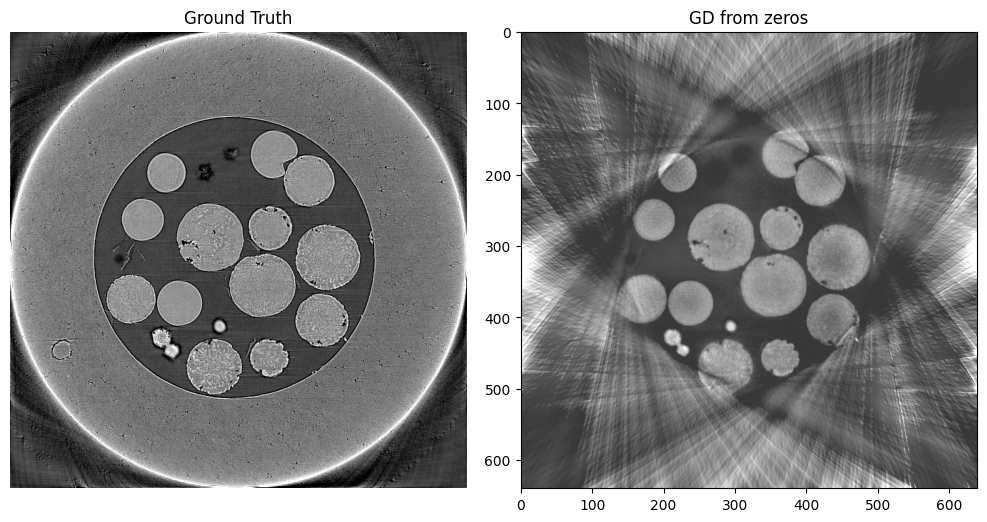

In [49]:
TEST_SLICE_IDX = NUM_SLICES // 2 
# Quick test: guidance from zero initialisation (uses SW projections since t=999 > threshold)
recons_gd = sinogram_guidance(
    projs_vrc=projections.to(device),
    angles_deg=full_angles_deg,
    vol_init=torch.zeros(gt_fbp.shape, device=device),
    num_gd_steps=None,
    max_epochs=8,
    lr=0.05,
    batch_size=30,
    verbose=True,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gt_fbp[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth')
axes[0].axis('off')
axes[1].imshow(recons_gd[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'GD from zeros')
plt.tight_layout()
plt.show()

In [50]:
# # Guidance hyperparameters
# GUIDANCE_EPOCHS     = 1
# GUIDANCE_LR         = 0.0002
# GUIDANCE_BATCH_SIZE = 30
# GUIDANCE_NUM_GD_STEPS = None

# Guidance hyperparameters
GUIDANCE_EPOCHS     = 1
GUIDANCE_LR         = 0.0005
GUIDANCE_BATCH_SIZE = 30
GUIDANCE_NUM_GD_STEPS = None

guidance = lambda x, t: sinogram_guidance(
    projs_vrc=projections.to(device),
    angles_deg=full_angles_deg,
    vol_init=x.to(device),
    max_epochs=GUIDANCE_EPOCHS,
    lr=GUIDANCE_LR,
    batch_size=GUIDANCE_BATCH_SIZE,
    num_gd_steps=GUIDANCE_NUM_GD_STEPS,
    timestep=int(t),
)

## 8. Run Guided DDIM on a Single Test Slice

Quick sanity check before the full sweep.

In [62]:
diffusion_recon = la_fbp.clone().to(device)

In [69]:
torch.cuda.empty_cache()
NUM_INFERENCE_STEPS = 50

noise_scheduler = GuidedDDIMScheduler(
    num_train_timesteps=1000,
    guidance_function=guidance,
)

pipeline = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler,
    fdk_prior=None,
    normalize_fn=normalize_fn,
    denormalize_fn=denormalize_fn,
    slice_batch_size=32,
)

result = pipeline.truncated_pipeline(
    initial_guess=diffusion_recon.to(device),                   # start from the guided reconstruction (can also start from zeros or FBP)
    start_step=int(0.0 * NUM_INFERENCE_STEPS),
    # batch_size=D,                       # single 2D slice: (1, H, W)
    num_inference_steps=NUM_INFERENCE_STEPS,
    use_clipped_model_output=True
)
diffusion_recon = result.images.squeeze(0)  # (B, H, W)
if len(diffusion_recon.shape) == 2:
    diffusion_recon = diffusion_recon.unsqueeze(0)  # (1, H, W)

print(f"Guided DDIM reconstruction done")
print(f"  shape: {diffusion_recon.shape}")
print(f"  range: [{diffusion_recon.min():.4f}, {diffusion_recon.max():.4f}]")

100%|██████████| 50/50 [00:05<00:00,  8.91it/s]

Guided DDIM reconstruction done
  shape: torch.Size([1, 640, 640])
  range: [0.0000, 0.0076]


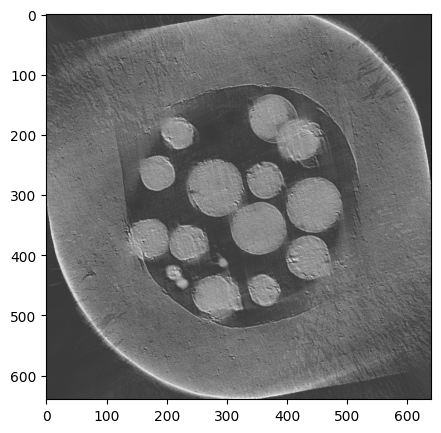

In [70]:
plt.imshow(diffusion_recon[0].cpu().detach(), cmap='gray', vmin=vmin, vmax=vmax)

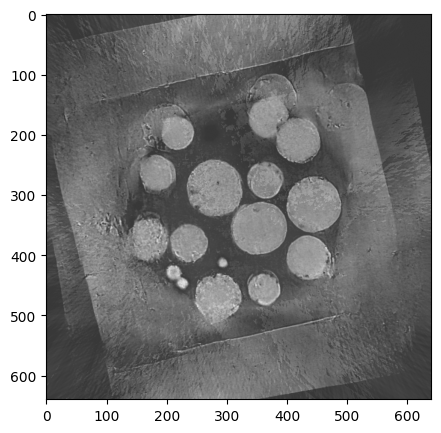

In [68]:
diffusion_recon = diffusion_recon.mean(dim=0).repeat(NUM_SLICES, 1, 1)

plt.imshow(diffusion_recon[:].mean(dim=0).cpu().detach(), cmap='gray', vmin=vmin, vmax=vmax)

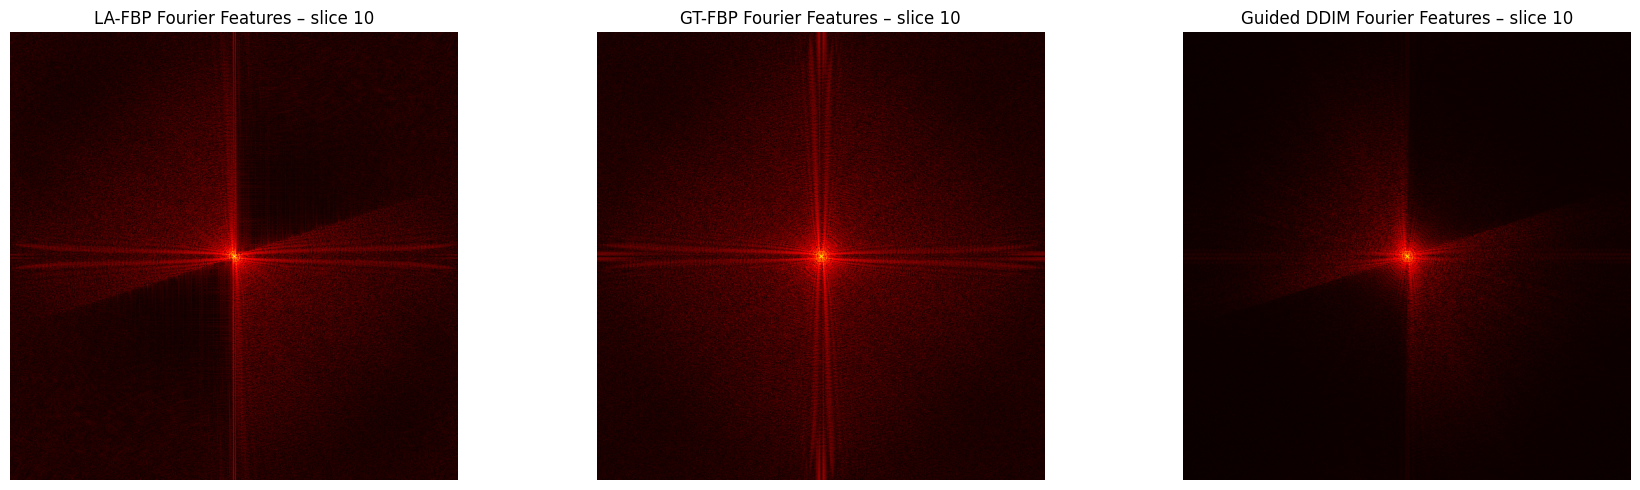

In [ ]:
fft_idx = PREVIEW_IDX if 'PREVIEW_IDX' in globals() else 0

fft_inputs = {
    'LA-FBP': la_fbp[fft_idx],
    'GT-FBP': gt_fbp[fft_idx],
    'Guided DDIM': diffusion_recon[fft_idx],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, image) in zip(axes, fft_inputs.items()):
    fft_recon = fft_2D(image)
    magnitude = torch.log1p(torch.abs(fft_recon))
    ax.imshow(magnitude.cpu().detach(), cmap='hot')
    ax.set_title(f'{title} Fourier Features – slice {fft_idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Multi-Slice Evaluation

Sweep over selected slices, compute per-slice PSNR / SSIM, and report aggregate statistics.

In [ ]:
from tqdm import tqdm

# Determine which slices to evaluate
if TEST_SLICE_INDICES is not None:
    eval_slices = list(TEST_SLICE_INDICES)
else:
    eval_slices = list(range(0, NUM_SLICES))

print(f"Evaluating {len(eval_slices)} slices: {eval_slices[:5]}{'...' if len(eval_slices) > 5 else ''}")

results = []
for k in tqdm(eval_slices, desc='DDIM inference'):
    ddim_recon = diffusion_recon[k].cpu().numpy()  # (H, W)
    gt_k  = gt_fbp[k].numpy()
    la_k  = la_fbp[k].numpy()
    dr    = gt_k.max() - gt_k.min()

    psnr_d = compute_psnr(gt_k, ddim_recon, data_range=dr)
    ssim_d = compute_ssim(gt_k, ddim_recon, data_range=dr)
    psnr_l = compute_psnr(gt_k, la_k,       data_range=dr)
    ssim_l = compute_ssim(gt_k, la_k,       data_range=dr)

    results.append({
        'slice':     k,
        'psnr_ddim': psnr_d,
        'ssim_ddim': ssim_d,
        'psnr_la':   psnr_l,
        'ssim_la':   ssim_l,
        'ddim_recon': ddim_recon,
        'la_fbp': la_k,
    })
    torch.cuda.empty_cache()

print("\nDone.")


Evaluating 20 slices: [0, 1, 2, 3, 4]...


DDIM inference: 100%|██████████| 20/20 [00:00<00:00, 24.96it/s]


Done.


## 10. Metrics Summary

 Slice   DDIM PSNR  DDIM SSIM   LA-FBP PSNR  LA-FBP SSIM
------------------------------------------------------------
     0       32.03     0.7512         31.36       0.7300
     1       32.03     0.7512         31.36       0.7300
     2       32.03     0.7512         31.36       0.7300
     3       32.03     0.7512         31.36       0.7300
     4       32.03     0.7512         31.36       0.7300
     5       32.03     0.7512         31.36       0.7300
     6       32.03     0.7512         31.36       0.7300
     7       32.03     0.7512         31.36       0.7300
     8       32.03     0.7512         31.36       0.7300
     9       32.03     0.7512         31.36       0.7300
    10       32.03     0.7512         31.36       0.7300
    11       32.03     0.7512         31.36       0.7300
    12       32.03     0.7512         31.36       0.7300
    13       32.03     0.7512         31.36       0.7300
    14       32.03     0.7512         31.36       0.7300
    15       32.03     0.75

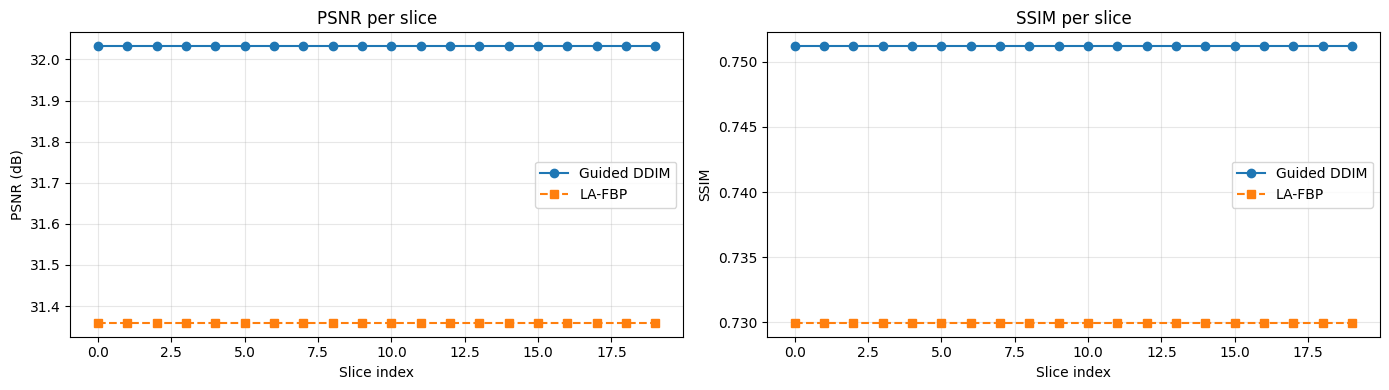

In [ ]:
psnr_ddim_all = [r['psnr_ddim'] for r in results]
ssim_ddim_all = [r['ssim_ddim'] for r in results]
psnr_la_all   = [r['psnr_la']   for r in results]
ssim_la_all   = [r['ssim_la']   for r in results]
slices_all    = [r['slice']      for r in results]

# ── Per-slice table ───────────────────────────────────────────────────────
print(f"{'Slice':>6}  {'DDIM PSNR':>10} {'DDIM SSIM':>10}  {'LA-FBP PSNR':>12} {'LA-FBP SSIM':>12}")
print("-" * 60)
for r in results:
    print(f"{r['slice']:>6d}  {r['psnr_ddim']:>10.2f} {r['ssim_ddim']:>10.4f}  "
          f"{r['psnr_la']:>12.2f} {r['ssim_la']:>12.4f}")
print("-" * 60)
print(f"{'Mean':>6}  {np.mean(psnr_ddim_all):>10.2f} {np.mean(ssim_ddim_all):>10.4f}  "
      f"{np.mean(psnr_la_all):>12.2f} {np.mean(ssim_la_all):>12.4f}")
print(f"{'Std':>6}  {np.std(psnr_ddim_all):>10.2f} {np.std(ssim_ddim_all):>10.4f}  "
      f"{np.std(psnr_la_all):>12.2f} {np.std(ssim_la_all):>12.4f}")

# ── PSNR / SSIM over slices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(slices_all, psnr_ddim_all, 'o-', label='Guided DDIM')
axes[0].plot(slices_all, psnr_la_all,   's--', label='LA-FBP')
axes[0].set_xlabel('Slice index')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR per slice')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(slices_all, ssim_ddim_all, 'o-', label='Guided DDIM')
axes[1].plot(slices_all, ssim_la_all,   's--', label='LA-FBP')
axes[1].set_xlabel('Slice index')
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM per slice')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Visual Comparison Gallery

In [ ]:
# optimizer = torch.optim.AdamW(
#     model.parameters()
# )
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
# }, CHECKPOINT_PATH)

/tmp/ipykernel_66662/1829170448.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err   = gt - ddim
/tmp/ipykernel_66662/1829170448.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err   = gt - la_k


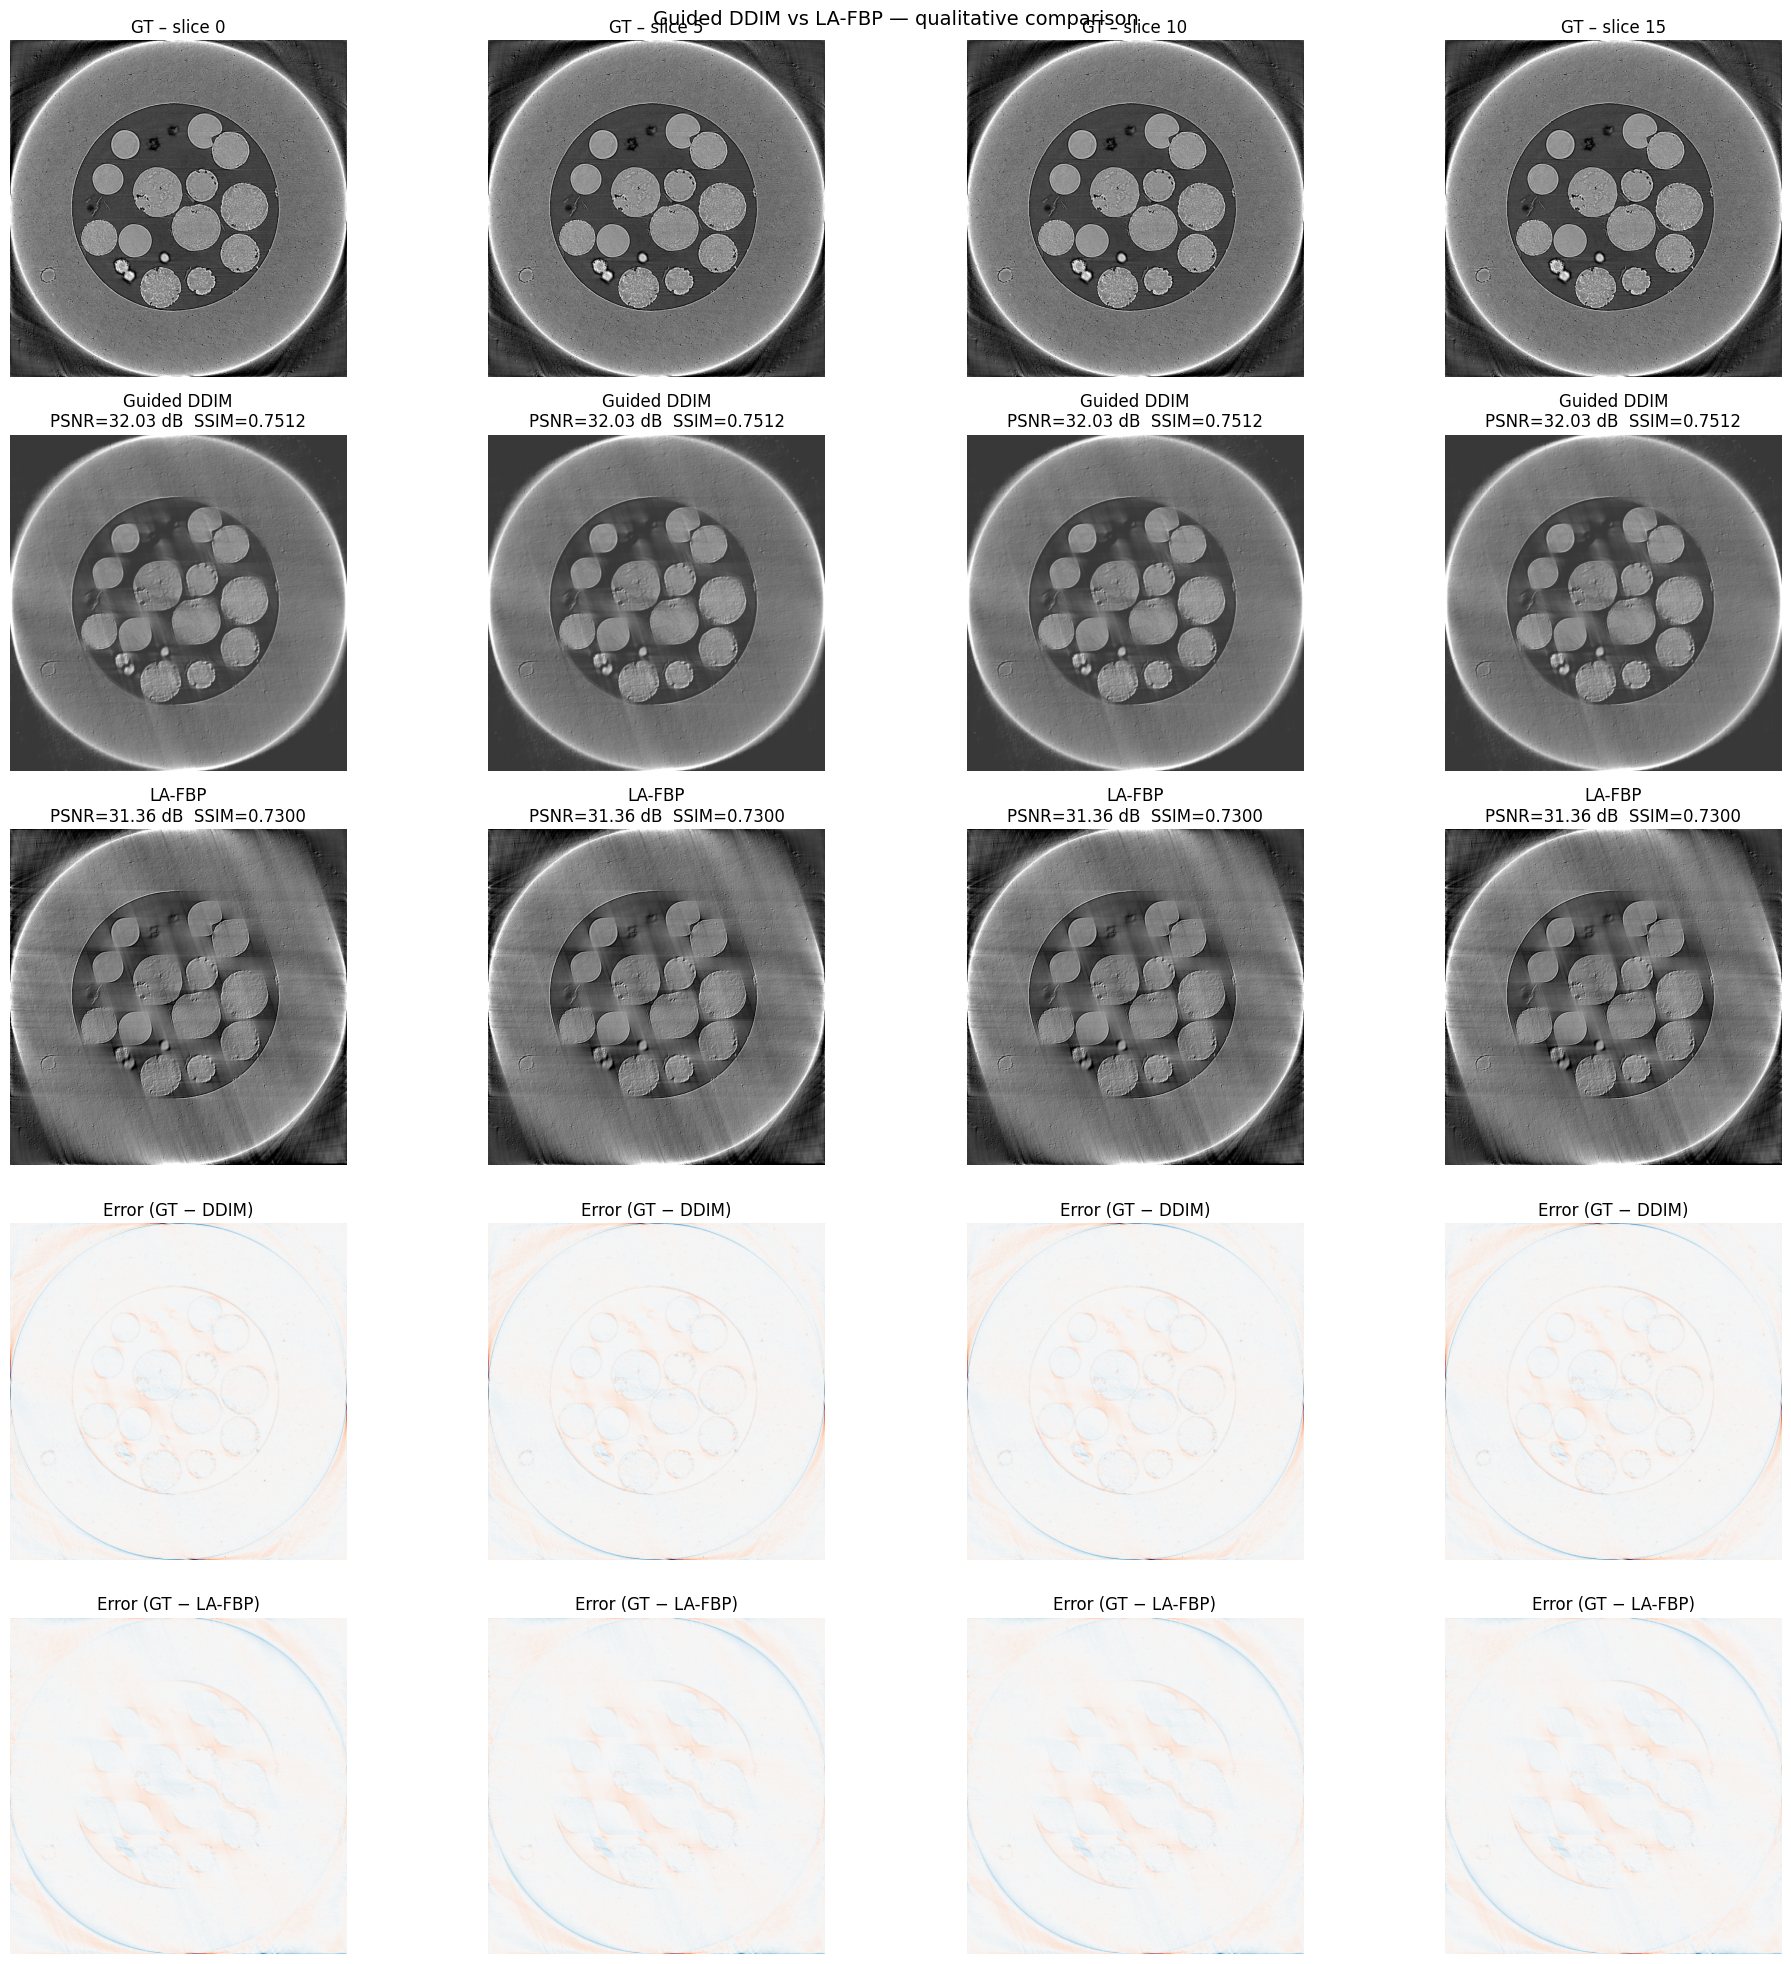

In [ ]:
# Show GT | DDIM | LA-FBP | error maps for up to 4 evenly-spaced results
show_results = results[::max(1, len(results) // 4)][:4]
ncols = len(show_results)

fig, axes = plt.subplots(5, ncols, figsize=(5 * ncols, 20))
if ncols == 1:
    axes = axes.reshape(-1, 1)

for col, r in enumerate(show_results):
    k   = r['slice']
    gt  = gt_fbp[k]
    la  = la_fbp[k]
    ddim = r['ddim_recon']
    la_k = r['la_fbp']
    vmin, vmax = np.percentile(gt, [1, 99])

    axes[0, col].imshow(gt,   cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'GT – slice {k}');    axes[0, col].axis('off')

    axes[1, col].imshow(ddim, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'Guided DDIM\nPSNR={r["psnr_ddim"]:.2f} dB  SSIM={r["ssim_ddim"]:.4f}')
    axes[1, col].axis('off')

    axes[2, col].imshow(la,   cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, col].set_title(f'LA-FBP\nPSNR={r["psnr_la"]:.2f} dB  SSIM={r["ssim_la"]:.4f}')
    axes[2, col].axis('off')

    err   = gt - ddim
    emax  = max(abs(err.min()), abs(err.max()))
    axes[3, col].imshow(err, cmap='RdBu', vmin=-emax, vmax=emax)
    axes[3, col].set_title(f'Error (GT − DDIM)');  axes[3, col].axis('off')

    err   = gt - la_k
    emax  = max(abs(err.min()), abs(err.max()))
    axes[4, col].imshow(err, cmap='RdBu', vmin=-emax, vmax=emax)
    axes[4, col].set_title(f'Error (GT − LA-FBP)');  axes[4, col].axis('off')

plt.suptitle('Guided DDIM vs LA-FBP — qualitative comparison', fontsize=14)
plt.tight_layout()
plt.show()


# Saving Results

In [ ]:
import os
import json

PATH = f"/myhome/data/sdate/shared/compression_paper/file_{FILE_IDX}_extracted/reconstruction"
# make sure the directory exists
os.makedirs(PATH, exist_ok=True)

diffusion_np = diffusion_recon.cpu().numpy()

np.save(PATH + f"/diffusion_{FILE_IDX}_1_round.npy", diffusion_np)